In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [2]:
# Leer y parsear el archivo log
def cargar_datos(path):
    with open(path, encoding='utf-8') as f:
        lineas = f.readlines()

    registros = []
    for linea in lineas:
        match = re.match(r"- (\d{4}-\d{2}-\d{2} \d{2}:\d{2}) \| ([\d.]+) min \| (.+)", linea.strip())
        if match:
            fecha = datetime.strptime(match[1], '%Y-%m-%d %H:%M')
            minutos = float(match[2])
            estado = match[3]
            registros.append((fecha, minutos, estado))

    df = pd.DataFrame(registros, columns=["fecha", "minutos", "estado"])
    df["hora"] = df["fecha"].dt.hour
    df["dia_semana"] = df["fecha"].dt.day_name()
    return df

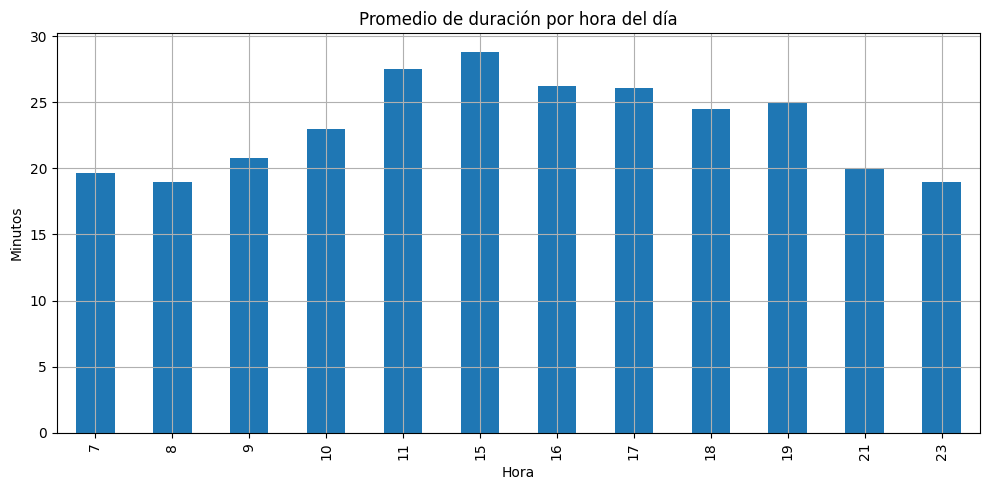

In [3]:
# Cargar datos
df = cargar_datos("trafico_log.md")

# Gráfico 1: duración por hora del día
plt.figure(figsize=(10, 5))
df.groupby("hora")["minutos"].mean().plot(kind="bar")
plt.title("Promedio de duración por hora del día")
plt.ylabel("Minutos")
plt.xlabel("Hora")
plt.grid(True)
plt.tight_layout()
plt.show()

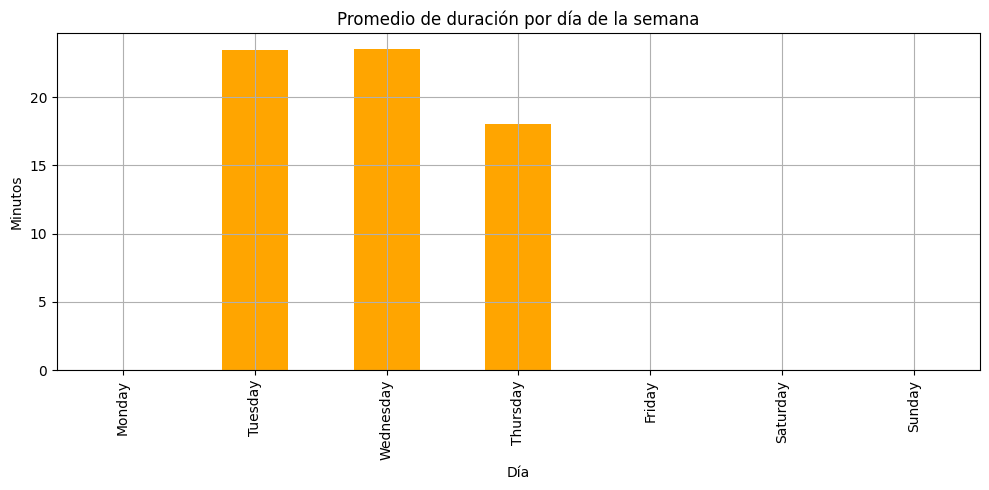

In [4]:
# Gráfico 2: promedio por día de la semana
plt.figure(figsize=(10, 5))
dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("dia_semana")["minutos"].mean().reindex(dias_orden).plot(kind="bar", color="orange")
plt.title("Promedio de duración por día de la semana")
plt.ylabel("Minutos")
plt.xlabel("Día")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Mostrar picos de tráfico
picos = df[df["minutos"] > 15].copy()
picos["fecha_str"] = picos["fecha"].dt.strftime('%Y-%m-%d %H:%M')
print("🔺 Registros con tráfico alto (>20min):")
display(picos[["fecha_str", "minutos", "estado"]])

🔺 Registros con tráfico alto (>20min):


,fecha_str,minutos,estado
0,2025-07-22 17:35,27.2,🚨 ALTO | 🚫 Sin peaje
1,2025-07-22 17:37,27.0,🚨 ALTO | 🚫 Sin peaje
2,2025-07-22 15:37,27.0,🚨 ALTO | 🚫 Sin peaje
3,2025-07-22 15:44,25.0,🚨 ALTO | 🚫 Sin peaje
4,2025-07-22 15:55,24.0,🚨 ALTO | 🚫 Sin peaje
5,2025-07-22 16:13,22.0,🚨 ALTO | 🚫 Sin peaje
6,2025-07-22 21:01,20.0,✅ OK | 🚫 Sin peaje
7,2025-07-22 21:05,20.0,✅ OK | 🚫 Sin peaje
8,2025-07-22 23:31,19.0,🚨 ALTO | 🚫 Sin peaje
9,2025-07-23 07:54,20.0,NORMAL | 🚫 Sin peaje
